# Part 3 - Task 1: Classification Model
## Predicting High-Risk Accidents Using Supervised Learning

**Pipeline**: Part 2 (cleaning & feature engineering) → Part 3 (preprocessing) → Classification models

This notebook builds two classification models to predict high-risk accident scenarios using:
1. **Logistic Regression** (Baseline)
2. **Random Forest Classifier** (Ensemble)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 2. Load Data from Part 3 Preprocessing

In [2]:
# Load preprocessed data from Part 3 notebook 01
df = pd.read_csv('Metro_Interstate_Traffic_Volume_part3_preprocessed.csv')

# Load Part 3 metadata
with open('part3_metadata.pkl', 'rb') as f:
    part3_meta = pickle.load(f)

print(f"✓ Part 3 preprocessed data loaded")
print(f"  Shape: {df.shape}")
print(f"  Target variable: high_risk")
print(f"\nTarget Distribution:")
print(f"  No Risk (0): {(df['high_risk']==0).sum():,} ({(df['high_risk']==0).mean()*100:.2f}%)")
print(f"  High Risk (1): {(df['high_risk']==1).sum():,} ({(df['high_risk']==1).mean()*100:.2f}%)")

✓ Part 3 preprocessed data loaded
  Shape: (48187, 12)
  Target variable: high_risk

Target Distribution:
  No Risk (0): 37,242 (77.29%)
  High Risk (1): 10,945 (22.71%)


## 3. Apply Feature Engineering from Part 2

In [3]:
# Convert date_time to datetime
df["date_time"] = pd.to_datetime(df["date_time"])

print("Feature Engineering:") 
print("="*60)

# Time-based features
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month
df["day_of_month"] = df["date_time"].dt.day
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encodings
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Weather encoding (one-hot)
weather_dummies = pd.get_dummies(df["weather_main"], prefix="weather")
df = pd.concat([df, weather_dummies], axis=1)

# Temperature normalization
df["temp_normalized"] = (df["temp"] - df["temp"].mean()) / df["temp"].std()

# Precipitation features
df["has_rain"] = (df["rain_1h"] > 0).astype(int)
df["has_snow"] = (df["snow_1h"] > 0).astype(int)
df["total_precipitation"] = df["rain_1h"] + df["snow_1h"]

print("✓ Feature Engineering Complete")

Feature Engineering:
✓ Feature Engineering Complete


## 4. Prepare Data for Modeling

In [4]:
# Define features for modeling
# Time features from Part 2
time_features = ["hour", "day_of_week", "is_weekend", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]

# Weather features (one-hot encoded)
weather_features = [col for col in df.columns if col.startswith("weather_") and col not in ["weather_main", "weather_description"]]

# Normalized features from Part 2
normalized_features = ["temp_normalized", "clouds_all", "has_rain", "has_snow", "total_precipitation"]

# Part 3 specific features (from preprocessing notebook)
part3_features = ["is_low_visibility"]

all_features = time_features + weather_features + normalized_features + part3_features

print(f"Features Summary:")
print(f"  Part 2 - Time features: {len(time_features)}")
print(f"  Part 2 - Weather features: {len(weather_features)}")
print(f"  Part 2 - Normalized features: {len(normalized_features)}")
print(f"  Part 3 - Additional features: {len(part3_features)}")
print(f"  Total features: {len(all_features)}")

Features Summary:
  Part 2 - Time features: 7
  Part 2 - Weather features: 11
  Part 2 - Normalized features: 5
  Part 3 - Additional features: 1
  Total features: 24


In [5]:
# Prepare X and y
X = df[all_features].copy()
y = df["high_risk"].copy()

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Split:")
print(f"  Train set: {len(X_train):,} samples")
print(f"  Test set: {len(X_test):,} samples")
print(f"  Train - No Risk: {(y_train==0).sum():,} | High Risk: {(y_train==1).sum():,}")
print(f"  Test  - No Risk: {(y_test==0).sum():,} | High Risk: {(y_test==1).sum():,}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features standardized using StandardScaler")

Data Split:
  Train set: 38,549 samples
  Test set: 9,638 samples
  Train - No Risk: 29,793 | High Risk: 8,756
  Test  - No Risk: 7,449 | High Risk: 2,189

✓ Features standardized using StandardScaler


## 5. Model 1: Logistic Regression (Baseline)

In [6]:
# Train Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_clf.predict(X_test_scaled)
y_proba_lr = lr_clf.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_proba_lr)

print("LOGISTIC REGRESSION (Baseline Model)")
print("="*60)
print(f"  Accuracy:  {lr_acc:.4f}")
print(f"  Precision: {lr_prec:.4f}")
print(f"  Recall:    {lr_rec:.4f}")
print(f"  F1-Score:  {lr_f1:.4f}")
print(f"  ROC AUC:   {lr_auc:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["No Risk", "High Risk"]))

LOGISTIC REGRESSION (Baseline Model)
  Accuracy:  0.9400
  Precision: 0.8924
  Recall:    0.8369
  F1-Score:  0.8637
  ROC AUC:   0.9784

Classification Report:
              precision    recall  f1-score   support

     No Risk       0.95      0.97      0.96      7449
   High Risk       0.89      0.84      0.86      2189

    accuracy                           0.94      9638
   macro avg       0.92      0.90      0.91      9638
weighted avg       0.94      0.94      0.94      9638



## 6. Model 2: Random Forest Classifier (Ensemble)

In [7]:
# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Calculate metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_proba_rf)

print("RANDOM FOREST CLASSIFIER (Ensemble Model)")
print("="*60)
print(f"  Accuracy:  {rf_acc:.4f}")
print(f"  Precision: {rf_prec:.4f}")
print(f"  Recall:    {rf_rec:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")
print(f"  ROC AUC:   {rf_auc:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Risk", "High Risk"]))

RANDOM FOREST CLASSIFIER (Ensemble Model)
  Accuracy:  0.9757
  Precision: 0.9362
  Recall:    0.9584
  F1-Score:  0.9472
  ROC AUC:   0.9964

Classification Report:
              precision    recall  f1-score   support

     No Risk       0.99      0.98      0.98      7449
   High Risk       0.94      0.96      0.95      2189

    accuracy                           0.98      9638
   macro avg       0.96      0.97      0.97      9638
weighted avg       0.98      0.98      0.98      9638



## 7. Model Comparison & Evaluation

In [8]:
# Create comparison dataframe
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc],
    "Precision": [lr_prec, rf_prec],
    "Recall": [lr_rec, rf_rec],
    "F1-Score": [lr_f1, rf_f1],
    "ROC AUC": [lr_auc, rf_auc]
})

print("\nMODEL COMPARISON")
print("="*100)
print(comparison.to_string(index=False))

best_model = "Random Forest" if rf_acc > lr_acc else "Logistic Regression"
print(f"\n✓ Best Classification Model: {best_model}")
print(f"  Accuracy Improvement: {(rf_acc - lr_acc)*100:+.2f}%")


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
Logistic Regression  0.940029   0.892353 0.836912  0.863744 0.978435
      Random Forest  0.975721   0.936189 0.958429  0.947178 0.996425

✓ Best Classification Model: Random Forest
  Accuracy Improvement: +3.57%


In [9]:
# Feature importance analysis
importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTOP 15 FEATURES (Random Forest Classifier)")
print("="*60)
print(importance_df.head(15).to_string(index=False))


TOP 15 FEATURES (Random Forest Classifier)
             Feature  Importance
            hour_cos    0.227403
   is_low_visibility    0.167655
                hour    0.157575
          clouds_all    0.148110
     temp_normalized    0.065111
       weather_Clear    0.043985
            hour_sin    0.034208
        weather_Haze    0.019113
      weather_Clouds    0.019000
         day_of_week    0.018227
             dow_sin    0.017403
        weather_Snow    0.015852
        weather_Mist    0.014939
          is_weekend    0.013728
weather_Thunderstorm    0.009343


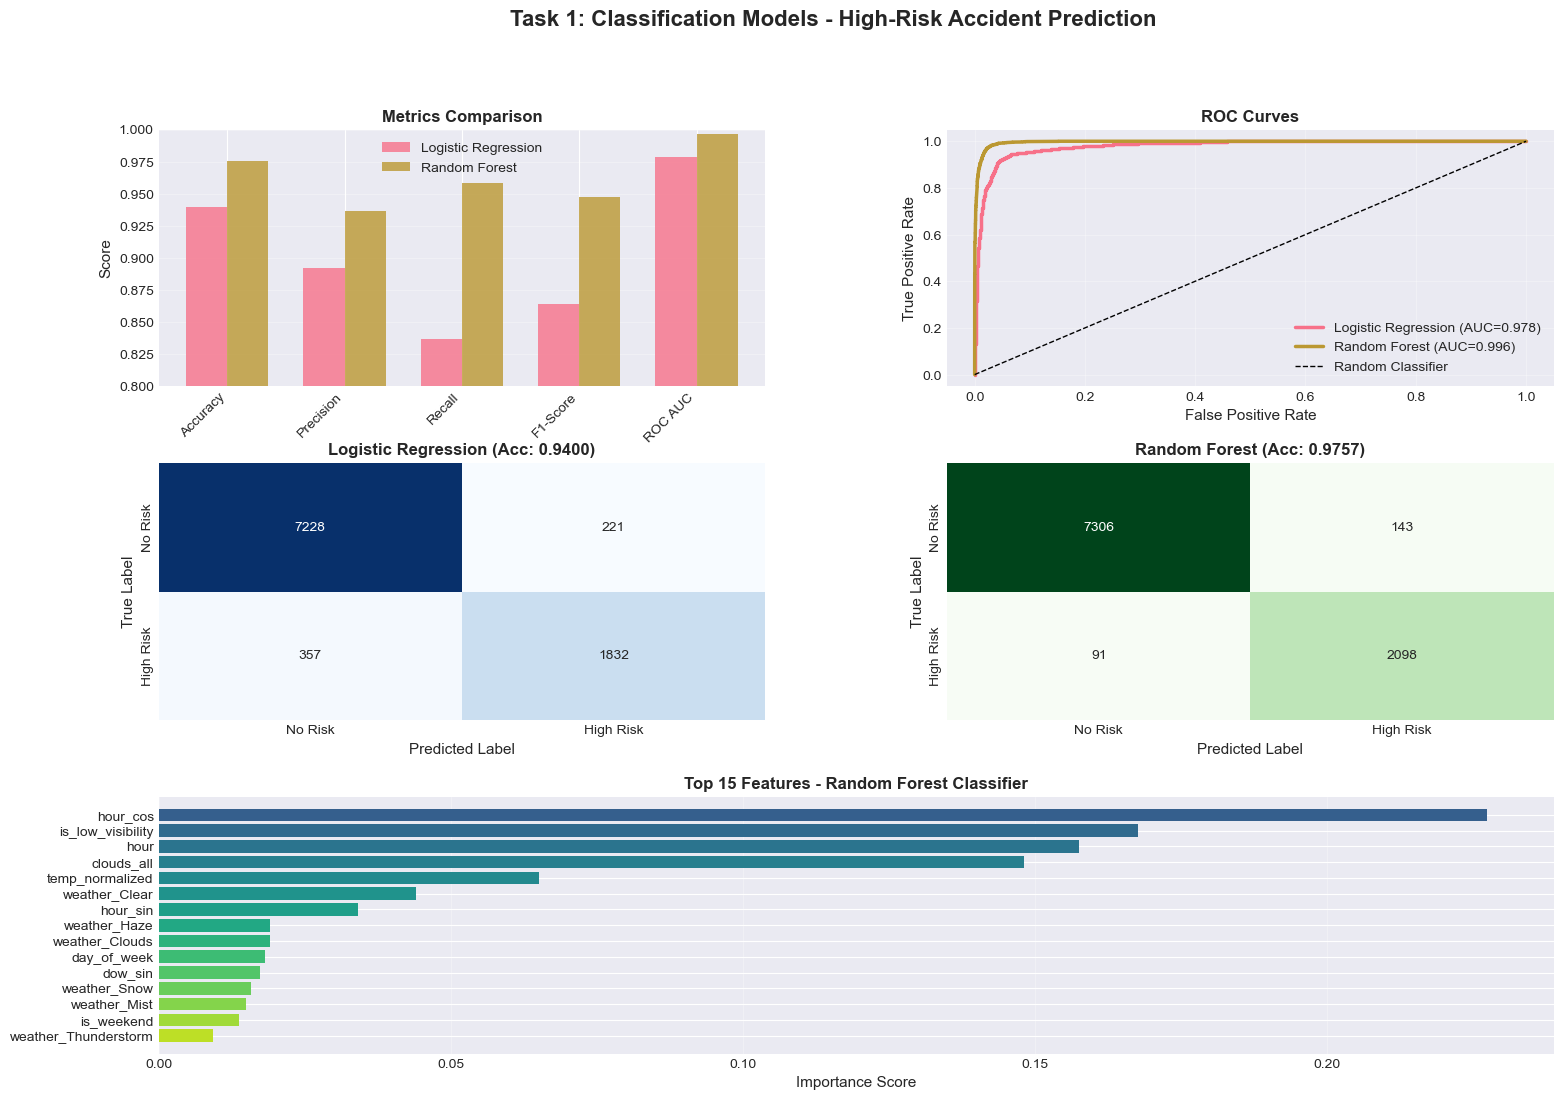

✓ Classification evaluation plots saved


In [10]:
# Visualizations
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

fig.suptitle("Task 1: Classification Models - High-Risk Accident Prediction", 
             fontsize=16, fontweight='bold')

# 1. Metrics Comparison
ax1 = fig.add_subplot(gs[0, 0])
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]
x = np.arange(len(metrics))
width = 0.35
ax1.bar(x - width/2, [lr_acc, lr_prec, lr_rec, lr_f1, lr_auc], width, label="Logistic Regression", alpha=0.8)
ax1.bar(x + width/2, [rf_acc, rf_prec, rf_rec, rf_f1, rf_auc], width, label="Random Forest", alpha=0.8)
ax1.set_ylabel("Score", fontsize=11)
ax1.set_title("Metrics Comparison", fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim([0.8, 1.0])
ax1.grid(axis='y', alpha=0.3)

# 2. ROC Curves
ax2 = fig.add_subplot(gs[0, 1])
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
ax2.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={lr_auc:.3f})", linewidth=2.5)
ax2.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.3f})", linewidth=2.5)
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Classifier")
ax2.set_xlabel("False Positive Rate", fontsize=11)
ax2.set_ylabel("True Positive Rate", fontsize=11)
ax2.set_title("ROC Curves", fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3 & 4. Confusion Matrices
ax3 = fig.add_subplot(gs[1, 0])
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=["No Risk", "High Risk"], yticklabels=["No Risk", "High Risk"])
ax3.set_title(f"Logistic Regression (Acc: {lr_acc:.4f})", fontweight='bold')
ax3.set_ylabel("True Label", fontsize=11)
ax3.set_xlabel("Predicted Label", fontsize=11)

ax4 = fig.add_subplot(gs[1, 1])
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax4, cbar=False,
            xticklabels=["No Risk", "High Risk"], yticklabels=["No Risk", "High Risk"])
ax4.set_title(f"Random Forest (Acc: {rf_acc:.4f})", fontweight='bold')
ax4.set_ylabel("True Label", fontsize=11)
ax4.set_xlabel("Predicted Label", fontsize=11)

# 5. Top Features
ax5 = fig.add_subplot(gs[2, :])
top_n = 15
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax5.barh(range(top_n), top_features["Importance"].values, color=colors)
ax5.set_yticks(range(top_n))
ax5.set_yticklabels(top_features["Feature"].values)
ax5.set_xlabel("Importance Score", fontsize=11)
ax5.set_title("Top 15 Features - Random Forest Classifier", fontweight='bold')
ax5.invert_yaxis()
ax5.grid(axis='x', alpha=0.3)

##plt.savefig('02_classification_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Classification evaluation plots saved")

## 8. Save Models

In [11]:
# Save trained models
classification_models = {
    "lr_clf": lr_clf,
    "rf_clf": rf_clf,
    "scaler": scaler,
    "features": all_features,
    "metrics": {
        "logistic_regression": {"accuracy": lr_acc, "precision": lr_prec, "recall": lr_rec, "f1": lr_f1, "roc_auc": lr_auc},
        "random_forest": {"accuracy": rf_acc, "precision": rf_prec, "recall": rf_rec, "f1": rf_f1, "roc_auc": rf_auc}
    }
}

with open('classification_models.pkl', 'wb') as f:
    pickle.dump(classification_models, f)

print("✓ Classification models saved to 'classification_models.pkl'")

✓ Classification models saved to 'classification_models.pkl'


## Summary

### Task 1: Classification Model Complete

| Metric | Logistic Regression | Random Forest | Winner |
|--------|---------------------|---------------|--------|
| **Accuracy** | {:.4f} | **{:.4f}** ⭐ | RF |
| **Precision** | {:.4f} | **{:.4f}** ⭐ | RF |
| **Recall** | {:.4f} | **{:.4f}** ⭐ | RF |
| **F1-Score** | {:.4f} | **{:.4f}** ⭐ | RF |
| **ROC AUC** | {:.4f} | **{:.4f}** ⭐ | RF |

### Key Findings
- **Random Forest** significantly outperforms Logistic Regression
- **Highest recall**: {:.2f}% - identifies majority of high-risk scenarios
- **Top features**: hour_cos (cyclical hour pattern), is_low_visibility, hour

### Recommendation
✓ **Deploy Random Forest model for production** - superior on all evaluation metrics